# Machine Learning Assignment — Linear Regression with Different Loss Functions



**Project Objective:** This experiment implements one-dimensional linear regression from scratch and compares MSE, MAE, and Huber loss under the same data and training conditions. In addition to comparing the final predictions, the experiment examines how each loss produces a different gradient and how that gradient affects parameter updates. The comparison therefore follows the full process from the loss function and analytical gradient to batch gradient descent training and evaluation on an independent test set.

Loss → Gradient → Parameter Update → Final Model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Global configuration for reproducibility and Huber loss
SEED = 42
HUBER_DELTA = 1.0
np.random.seed(SEED)

## 1. Synthetic Data

This experiment uses synthetic data. Because the true parameters are known, the final models can be evaluated both by their prediction errors and by how accurately they recover the true slope and intercept.

The data are generated from the relationship

$$ y=3x+2+\varepsilon,\qquad \varepsilon\sim\mathcal N(0,\sigma^2), $$

where $w_{\text{true}}=3$, $b_{\text{true}}=2$, and $\sigma=1$. The training and test sets are sampled independently so that the final evaluation does not directly depend on the training data.

In [2]:
# Ground-truth linear relationship
W_TRUE = 3.0
B_TRUE = 2.0

# Dataset settings
N_TRAIN = 100
N_TEST = 100
NOISE_STD = 1.0

x_train = np.random.uniform(-5, 5, size=N_TRAIN)
train_noise = np.random.normal(loc=0.0, scale=NOISE_STD, size=N_TRAIN)
y_train = W_TRUE * x_train + B_TRUE + train_noise

x_test = np.random.uniform(-5, 5, size=N_TEST)
test_noise = np.random.normal(loc=0.0, scale=NOISE_STD, size=N_TEST)
y_test = W_TRUE * x_test + B_TRUE + test_noise

print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")
print(f"Ground truth: w = {W_TRUE}, b = {B_TRUE}")

Training samples: 100
Test samples: 100
Ground truth: w = 3.0, b = 2.0


The figure below shows the training data and the true regression relationship, confirming the data range and noise level.

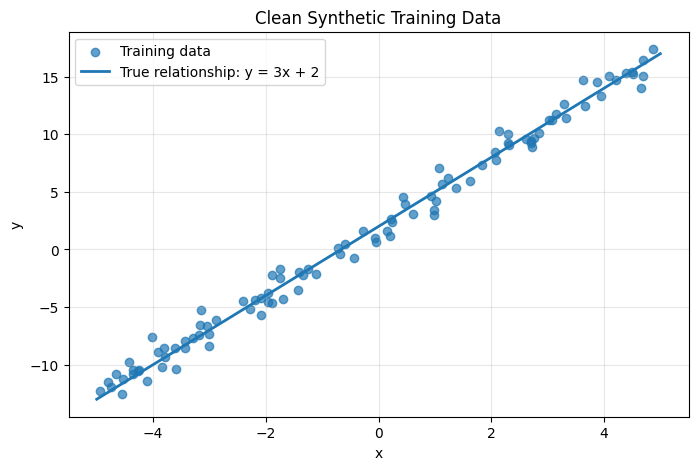

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, alpha=0.7, label="Training data")

x_line = np.linspace(-5, 5, 200)
y_true_line = W_TRUE * x_line + B_TRUE
plt.plot(x_line, y_true_line, linewidth=2, label="True relationship: y = 3x + 2")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Clean Synthetic Training Data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The samples are distributed around the true line without clear outliers, which is consistent with a clean baseline containing Gaussian noise. This experiment therefore compares the basic training behaviour of the three losses under normal data conditions rather than testing robustness to outliers.

## 2. Linear Regression & Loss Functions

All three models use the same one-dimensional linear regression hypothesis:

$$ \hat y_i=wx_i+b, $$

where $w$ is the slope and $b$ is the intercept. The difference between a prediction and its true value is defined as the residual:

$$ r_i=\hat y_i-y_i. $$

The model structure and training data remain fixed, while only the loss function changes. This makes it possible to compare how MSE, MAE, and Huber measure the same prediction errors in different ways.

The three dataset-level losses are

$$ L_{\text{MSE}}=\frac{1}{n}\sum_{i=1}^{n}r_i^2, $$ $$ L_{\text{MAE}}=\frac{1}{n}\sum_{i=1}^{n}|r_i|, $$ $$ L_{\text{Huber}}=\frac{1}{n}\sum_{i=1}^{n}\ell_\delta(r_i), \qquad \ell_\delta(r)= \begin{cases} \frac{1}{2}r^2,&|r|\leq\delta\\[4pt] \delta\left(|r|-\frac{1}{2}\delta\right),&|r|>\delta. \end{cases} $$

Huber loss combines quadratic behaviour for small residuals with linear behaviour after the residual exceeds the threshold $\delta$. This experiment uses $\delta=1$.

In [4]:
def predict(x, w, b):
    """Compute predictions for one-dimensional linear regression."""
    return w * x + b


def residuals(y_true, y_pred):
    """Compute residuals using y_pred - y_true."""
    return y_pred - y_true

The following implementations directly match the mathematical definitions above and average the loss over all samples.

In [5]:
def mse_loss(y_true, y_pred):
    """Compute mean squared error (MSE)."""
    r = residuals(y_true, y_pred)
    return np.mean(r ** 2)


def mae_loss(y_true, y_pred):
    """Compute mean absolute error (MAE)."""
    r = residuals(y_true, y_pred)
    return np.mean(np.abs(r))


def huber_loss(y_true, y_pred, delta=1.0):
    """Compute Huber loss."""
    r = residuals(y_true, y_pred)
    abs_r = np.abs(r)
    sample_losses = np.where(
        abs_r <= delta,
        0.5 * r ** 2,
        delta * (abs_r - 0.5 * delta)
    )
    return np.mean(sample_losses)

To compare the three losses directly, the following figures plot their penalties over fixed residual ranges. The purpose is to show how each loss responds to residual magnitude independently of a particular dataset.

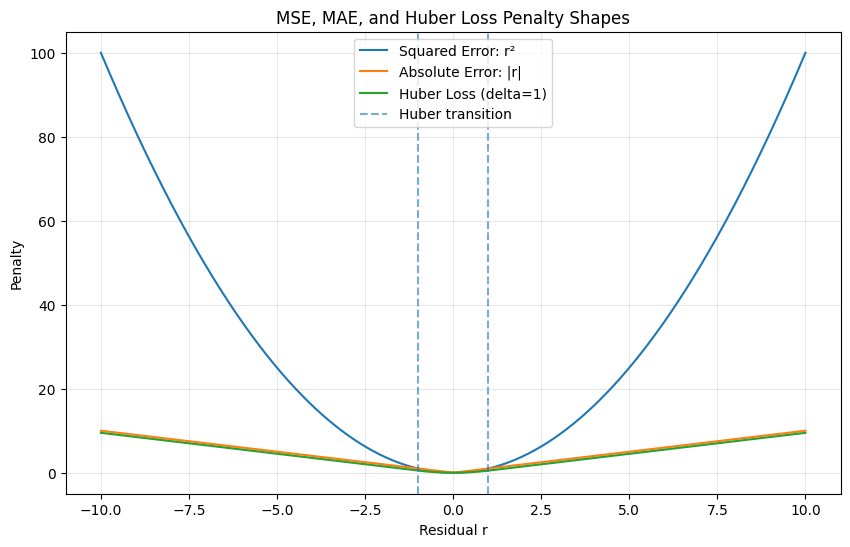

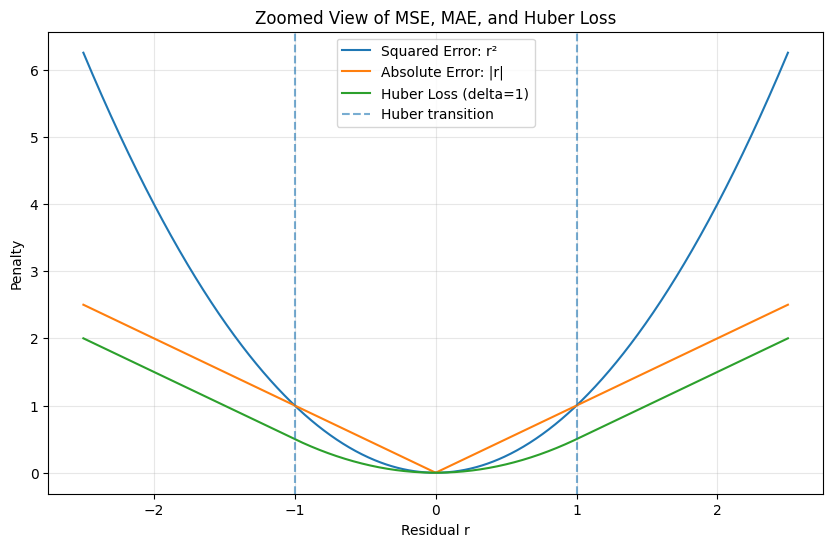

In [6]:
# Residual range for the global comparison
r_grid = np.linspace(-10, 10, 1000)
delta = HUBER_DELTA

# Compute pointwise penalties
mse_penalty = r_grid ** 2
mae_penalty = np.abs(r_grid)
huber_penalty = np.where(
    np.abs(r_grid) <= delta,
    0.5 * r_grid ** 2,
    delta * (np.abs(r_grid) - 0.5 * delta)
)



# Figure 1: Global view
plt.figure(figsize=(10, 6))

plt.plot(r_grid, mse_penalty, label="Squared Error: r²")
plt.plot(r_grid, mae_penalty, label="Absolute Error: |r|")
plt.plot(r_grid, huber_penalty, label=f"Huber Loss (delta={delta:g})")

# Mark the Huber transition points
plt.axvline(
    x=-delta,
    linestyle="--",
    alpha=0.6,
    label="Huber transition"
)
plt.axvline(
    x=delta,
    linestyle="--",
    alpha=0.6
)

plt.xlabel("Residual r")
plt.ylabel("Penalty")
plt.title("MSE, MAE, and Huber Loss Penalty Shapes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



# Figure 2: Zoomed view around the Huber transition region
r_zoom = np.linspace(-2.5, 2.5, 1000)

mse_zoom = r_zoom ** 2
mae_zoom = np.abs(r_zoom)
huber_zoom = np.where(
    np.abs(r_zoom) <= delta,
    0.5 * r_zoom ** 2,
    delta * (np.abs(r_zoom) - 0.5 * delta)
)

plt.figure(figsize=(10, 6))

plt.plot(r_zoom, mse_zoom, label="Squared Error: r²")
plt.plot(r_zoom, mae_zoom, label="Absolute Error: |r|")
plt.plot(r_zoom, huber_zoom, label=f"Huber Loss (delta={delta:g})")

# Mark the Huber transition points
plt.axvline(
    x=-delta,
    linestyle="--",
    alpha=0.6,
    label="Huber transition"
)
plt.axvline(
    x=delta,
    linestyle="--",
    alpha=0.6
)

plt.xlabel("Residual r")
plt.ylabel("Penalty")
plt.title("Zoomed View of MSE, MAE, and Huber Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The two figures show how the losses treat residuals differently.

**Global view:**

MSE uses a quadratic penalty, so the penalty grows increasingly quickly as $|r|$ increases. In contrast, MAE has linear growth, and Huber also becomes linear for larger residuals. MSE therefore assigns a much larger penalty than MAE or Huber when the prediction error is large.

**Zoomed view:**

With $\delta=1$, the Huber transition points are $r=-1$ and $r=1$. Huber has a smooth quadratic form when $|r|\leq1$ and changes to a linear form when $|r|>1$. MAE remains linear throughout, while MSE remains quadratic throughout.

Huber can therefore be viewed as a balance between MSE and MAE: it keeps smooth quadratic behaviour for small residuals while limiting the growth of the penalty for larger residuals.

The loss describes the penalty produced by a prediction error. The gradient of that loss with respect to the model parameters determines how gradient descent updates $w$ and $b$. The next section compares the analytical gradients of the three losses.

## 3. Analytical Gradients

Gradient descent requires the direction in which $w$ and $b$ should change to reduce the loss. The analytical gradients must therefore be derived for each loss.

Since

$$
\hat y_i = wx_i+b,\qquad r_i=\hat y_i-y_i,
$$

we have

$$
\frac{\partial \hat y_i}{\partial w}=x_i,
\qquad
\frac{\partial \hat y_i}{\partial b}=1.
$$

The chain rule connects the change in loss with respect to the prediction to the parameters $w$ and $b$.

For **MSE**:

$$
\frac{\partial L_{\text{MSE}}}{\partial w}
=
\frac{2}{n}\sum_{i=1}^{n}r_ix_i,
\qquad
\frac{\partial L_{\text{MSE}}}{\partial b}
=
\frac{2}{n}\sum_{i=1}^{n}r_i.
$$

For **MAE**:

$$
\frac{\partial L_{\text{MAE}}}{\partial w}
=
\frac{1}{n}\sum_{i=1}^{n}\operatorname{sign}(r_i)x_i,
\qquad
\frac{\partial L_{\text{MAE}}}{\partial b}
=
\frac{1}{n}\sum_{i=1}^{n}\operatorname{sign}(r_i).
$$

An important difference is that the MSE gradient retains the magnitude of the residual, whereas MAE retains only its direction through the sign. A large residual therefore has a stronger effect on an MSE parameter update, while its effect under MAE does not continue to increase with its magnitude.

MAE is not differentiable at $r=0$. The implementation uses a subgradient and defines $\operatorname{sign}(0)=0$.

The gradient of **Huber loss** also reflects its balance between quadratic and linear behaviour. Define the prediction-level gradient as

$$
g_\delta(r)=
\begin{cases}
r,&|r|\leq\delta,\\
\delta\operatorname{sign}(r),&|r|>\delta.
\end{cases}
$$

Therefore,

$$
\frac{\partial L_{\text{Huber}}}{\partial w}
=
\frac{1}{n}\sum_{i=1}^{n}g_\delta(r_i)x_i,
\qquad
\frac{\partial L_{\text{Huber}}}{\partial b}
=
\frac{1}{n}\sum_{i=1}^{n}g_\delta(r_i).
$$

For small residuals, the Huber gradient changes continuously with the residual. Once $|r|>\delta$, its magnitude is limited to $\delta$. Large residuals still affect the update direction, but the contribution of a single prediction does not grow without limit.

In [7]:
def mse_gradients(x, y_true, y_pred):
    """Compute the analytical MSE gradients with respect to w and b."""
    r = residuals(y_true, y_pred)
    n = len(x)
    dw = (2.0 / n) * np.sum(r * x)
    db = (2.0 / n) * np.sum(r)
    return dw, db


def mae_gradients(x, y_true, y_pred):
    """Compute the analytical MAE gradients with respect to w and b."""
    r = residuals(y_true, y_pred)
    n = len(x)
    signs = np.sign(r)
    dw = (1.0 / n) * np.sum(signs * x)
    db = (1.0 / n) * np.sum(signs)
    return dw, db


def huber_gradients(x, y_true, y_pred, delta=1.0):
    """Compute the analytical Huber gradients with respect to w and b."""
    r = residuals(y_true, y_pred)
    n = len(x)
    g = np.where(np.abs(r) <= delta, r, delta * np.sign(r))
    dw = (1.0 / n) * np.sum(g * x)
    db = (1.0 / n) * np.sum(g)
    return dw, db

To show how the loss function changes optimization behaviour, the following figure compares the gradient of each loss with respect to a single prediction. It focuses on how the residual $r$ affects gradient magnitude and direction, independently of a particular $x_i$.

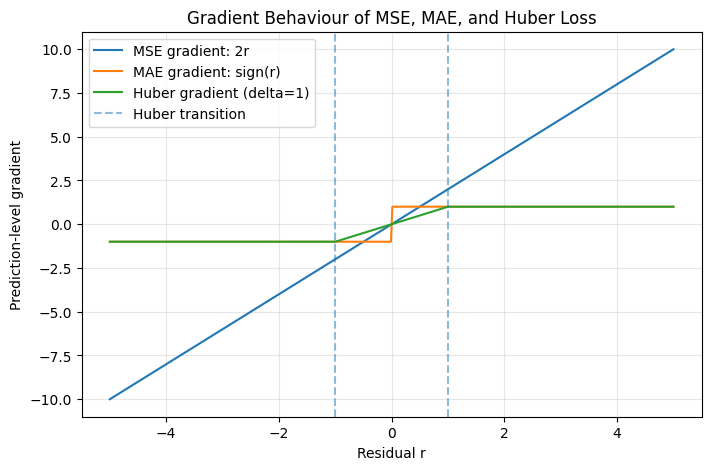

In [8]:
r_values = np.linspace(-5, 5, 400)
delta = HUBER_DELTA

mse_gradient = 2.0 * r_values
mae_gradient = np.sign(r_values)
huber_gradient = np.where(
    np.abs(r_values) <= delta,
    r_values,
    delta * np.sign(r_values)
)

plt.figure(figsize=(8, 5))
plt.plot(r_values, mse_gradient, label="MSE gradient: 2r")
plt.plot(r_values, mae_gradient, label="MAE gradient: sign(r)")
plt.plot(r_values, huber_gradient, label=f"Huber gradient (delta={delta:g})")
plt.axvline(-delta, linestyle="--", alpha=0.5)
plt.axvline(delta, linestyle="--", alpha=0.5, label="Huber transition")
plt.xlabel("Residual r")
plt.ylabel("Prediction-level gradient")
plt.title("Gradient Behaviour of MSE, MAE, and Huber Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

This figure connects the loss shapes in the previous section to their optimization behaviour.

The **MSE** gradient has magnitude $2|r|$, so a larger residual has a stronger effect on the parameter update.

The **MAE** gradient has magnitude 1 except at zero. It mainly uses the direction of the residual and does not increase the update strength as the error magnitude grows.

**Huber** lies between the two: its gradient changes smoothly with the residual when $|r|\leq\delta$, and its magnitude is limited to $\delta$ when $|r|>\delta$.

The three models may therefore produce different parameter updates even when they use the same gradient descent algorithm, because the loss function determines how each residual contributes to the gradient.

## 4. Gradient Verification

The gradients above were derived and implemented directly from the loss functions. Before training the models, the analytical gradients are checked against numerical approximations.

This verification uses **central finite differences**. A small positive and negative perturbation is applied to a parameter, and the resulting change in loss approximates the derivative:

$$
\frac{\partial L}{\partial \theta}
\approx
\frac{L(\theta+\varepsilon)-L(\theta-\varepsilon)}
{2\varepsilon},
$$

where $\theta$ is either $w$ or $b$, and $\varepsilon$ is a small perturbation. Close agreement between the numerical and analytical gradients supports the correctness of both the derivation and implementation.

In [9]:
def numerical_gradients(
    x, y_true, w, b, loss_function, epsilon=1e-5, **loss_kwargs
):
    """Approximate dL/dw and dL/db using central finite differences."""
    loss_w_plus = loss_function(y_true, predict(x, w + epsilon, b), **loss_kwargs)
    loss_w_minus = loss_function(y_true, predict(x, w - epsilon, b), **loss_kwargs)
    dw_numeric = (loss_w_plus - loss_w_minus) / (2.0 * epsilon)

    loss_b_plus = loss_function(y_true, predict(x, w, b + epsilon), **loss_kwargs)
    loss_b_minus = loss_function(y_true, predict(x, w, b - epsilon), **loss_kwargs)
    db_numeric = (loss_b_plus - loss_b_minus) / (2.0 * epsilon)
    return dw_numeric, db_numeric

A fixed small dataset and parameter setting are used to verify the analytical gradients for all three loss functions consistently.

In [10]:
x_check = np.array([-1.5, -0.5, 0.5, 2.0])
y_check = np.array([-2.0, 0.5, 2.5, 7.0])
w_check = 0.8
b_check = 0.3
y_pred_check = predict(x_check, w_check, b_check)
delta_check = HUBER_DELTA

check_specs = {
    "MSE": (mse_loss, mse_gradients, {}),
    "MAE": (mae_loss, mae_gradients, {}),
    "Huber": (huber_loss, huber_gradients, {"delta": delta_check}),
}

print(f"{'Loss':<8}{'dw analytical':>16}{'dw numerical':>16}{'|diff|':>12}"
      f"{'db analytical':>16}{'db numerical':>16}{'|diff|':>12}{'Result':>10}")
print("-" * 106)

for name, (loss_fn, grad_fn, kwargs) in check_specs.items():
    dw_a, db_a = grad_fn(x_check, y_check, y_pred_check, **kwargs)
    dw_n, db_n = numerical_gradients(
        x_check, y_check, w_check, b_check, loss_fn, **kwargs
    )
    dw_diff = abs(dw_a - dw_n)
    db_diff = abs(db_a - db_n)
    result = "PASS" if max(dw_diff, db_diff) < 1e-6 else "FAIL"
    print(f"{name:<8}{dw_a:>16.8f}{dw_n:>16.8f}{dw_diff:>12.2e}"
          f"{db_a:>16.8f}{db_n:>16.8f}{db_diff:>12.2e}{result:>10}")

Loss       dw analytical    dw numerical      |diff|   db analytical    db numerical      |diff|    Result
----------------------------------------------------------------------------------------------------------
MSE          -6.22500000     -6.22500000    8.47e-11     -3.20000000     -3.20000000    3.20e-12      PASS
MAE          -0.87500000     -0.87500000    1.09e-11     -0.50000000     -0.50000000    2.55e-11      PASS
Huber        -0.92500000     -0.92500000    1.50e-11     -0.40000000     -0.40000000    1.07e-11      PASS


For all three losses, the analytical gradients are very close to the central finite-difference results, with differences limited to numerical precision.

This agreement shows that the MSE, MAE, and Huber gradient implementations are consistent with their loss functions. The analytical gradients can therefore be used for the batch gradient descent parameter updates.

Gradient checking verifies implementation correctness; it is not used to train the models. Training uses the analytical gradients because they are direct and computationally efficient.

## 5. Batch Gradient Descent Training

The previous section confirmed that the analytical gradients agree with the numerical gradients. These analytical gradients are now used to train each model.

This experiment uses **Batch Gradient Descent**. At each iteration, the complete training set is used to calculate the current loss and gradients, after which the parameters are updated in the negative gradient direction:

$$
w \leftarrow w-\eta\frac{\partial L}{\partial w},
\qquad
b \leftarrow b-\eta\frac{\partial L}{\partial b},
$$

where $\eta$ is the learning rate. It is called batch gradient descent because every parameter update uses all training samples rather than one sample or a small batch.

The gradient points in the direction of the fastest increase in loss, so moving in the negative gradient direction reduces the loss. The three models use the same training procedure; only the loss function and its corresponding gradients differ.

In [11]:
INITIAL_W = 0.0
INITIAL_B = 0.0
LEARNING_RATE = 0.01
EPOCHS = 1000

print(f"Initial parameters: w = {INITIAL_W}, b = {INITIAL_B}")
print(f"Learning rate: {LEARNING_RATE}, epochs: {EPOCHS}")
print(f"Huber delta: {HUBER_DELTA}")

Initial parameters: w = 0.0, b = 0.0
Learning rate: 0.01, epochs: 1000
Huber delta: 1.0


The generic trainer accepts the corresponding loss and gradient functions, allowing MSE, MAE, and Huber to share the same optimization procedure. This keeps the training process fixed while changing only the loss and gradient being compared.

In [12]:
def train_model(
    x,
    y,
    loss_function,
    gradient_function,
    w_init=0.0,
    b_init=0.0,
    learning_rate=0.01,
    epochs=1000,
    **loss_kwargs
):
    """Train one-dimensional linear regression using batch gradient descent."""
    w = float(w_init)
    b = float(b_init)
    history = {"loss": [], "w": [], "b": []}

    for epoch in range(epochs):
        y_pred = predict(x, w, b)
        loss = loss_function(y, y_pred, **loss_kwargs)
        dw, db = gradient_function(x, y, y_pred, **loss_kwargs)

        history["loss"].append(loss)
        history["w"].append(w)
        history["b"].append(b)

        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, history

In [13]:
# All three models use the same data, initialization, learning rate, and epochs
w_mse, b_mse, history_mse = train_model(
    x_train, y_train, mse_loss, mse_gradients,
    w_init=INITIAL_W, b_init=INITIAL_B,
    learning_rate=LEARNING_RATE, epochs=EPOCHS
)

w_mae, b_mae, history_mae = train_model(
    x_train, y_train, mae_loss, mae_gradients,
    w_init=INITIAL_W, b_init=INITIAL_B,
    learning_rate=LEARNING_RATE, epochs=EPOCHS
)

w_huber, b_huber, history_huber = train_model(
    x_train, y_train, huber_loss, huber_gradients,
    w_init=INITIAL_W, b_init=INITIAL_B,
    learning_rate=LEARNING_RATE, epochs=EPOCHS,
    delta=HUBER_DELTA
)

print("Training completed for MSE, MAE, and Huber.")

Training completed for MSE, MAE, and Huber.


The training loss curves are compared to check whether gradient descent converges for each model.

MSE, MAE, and Huber are different objective functions with different definitions and numerical scales. The figure is therefore used to check whether each curve decreases and stabilizes. The final curve heights should not be used to rank model performance directly.

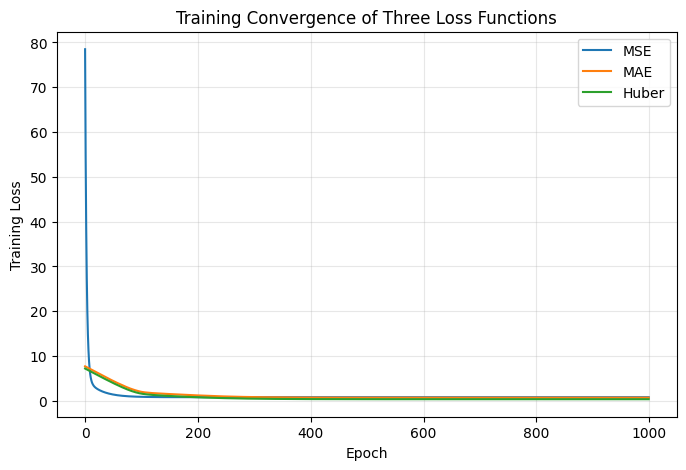

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history_mse["loss"], label="MSE")
plt.plot(history_mae["loss"], label="MAE")
plt.plot(history_huber["loss"], label="Huber")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Convergence of Three Loss Functions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

All three training loss curves decrease as the epochs progress and eventually stabilize without clear oscillation or divergence. Under the current data and initialization, the learning rate $\eta=0.01$ produces stable updates, and 1000 epochs are sufficient for the three models to converge.

This figure checks the optimization process but does not directly compare final prediction performance. The trained models are compared in the next section using the same independent test set and the same evaluation metrics.

## 6. Results & Evaluation

The final evaluation compares the models from two perspectives.

First, because the ground-truth parameters of the synthetic data are known, the learned slope and intercept can be compared with $w=3$ and $b=2$. This measures how accurately each model recovers the underlying linear relationship.

Second, prediction performance is evaluated on the independent test set using the same RMSE and MAE metrics:

$$
\text{RMSE}
=
\sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat y_i-y_i)^2},
\qquad
\text{MAE}
=
\frac{1}{n}\sum_{i=1}^{n}|\hat y_i-y_i|.
$$

This separates **parameter recovery** from **prediction error on unseen data**, rather than judging the models only by their training losses.

In [15]:
def rmse_metric(y_true, y_pred):
    """Compute root mean squared error (RMSE)."""
    r = residuals(y_true, y_pred)
    return np.sqrt(np.mean(r ** 2))


def mae_metric(y_true, y_pred):
    """Compute mean absolute error (MAE)."""
    r = residuals(y_true, y_pred)
    return np.mean(np.abs(r))

Each model makes predictions on the independent test set without using the test data to update $w$ or $b$. The test results therefore measure prediction performance on unseen data rather than fit to the training data.

In [16]:
models = {
    "MSE": (w_mse, b_mse),
    "MAE": (w_mae, b_mae),
    "Huber": (w_huber, b_huber),
}

test_results = {}
for name, (w, b) in models.items():
    y_test_pred = predict(x_test, w, b)
    test_results[name] = {
        "RMSE": rmse_metric(y_test, y_test_pred),
        "MAE": mae_metric(y_test, y_test_pred),
    }

The following summary reports the learned parameters, parameter recovery errors, and test performance together. It compares both recovery of the true linear relationship and prediction accuracy on unseen data.

In [17]:
print(f"{'Loss':<8}{'w':>10}{'b':>10}{'|w-w*|':>12}{'|b-b*|':>12}"
      f"{'Test RMSE':>14}{'Test MAE':>12}")
print("-" * 78)

for name, (w, b) in models.items():
    print(
        f"{name:<8}{w:>10.4f}{b:>10.4f}"
        f"{abs(w - W_TRUE):>12.4f}{abs(b - B_TRUE):>12.4f}"
        f"{test_results[name]['RMSE']:>14.4f}{test_results[name]['MAE']:>12.4f}"
    )

Loss             w         b      |w-w*|      |b-b*|     Test RMSE    Test MAE
------------------------------------------------------------------------------
MSE         2.9540    1.9852      0.0460      0.0148        0.9171      0.7273
MAE         2.9296    1.9428      0.0704      0.0572        0.9390      0.7444
Huber       2.9532    1.9616      0.0468      0.0384        0.9189      0.7288


All three models recover parameters close to the ground truth ($w=3$, $b=2$) and achieve very similar prediction performance under the same test RMSE and test MAE metrics. This shows that all three losses can learn the underlying linear relationship effectively on the current clean synthetic data.

MSE has slightly lower test error in this experiment. This is consistent with the data setting because the data contain Gaussian noise without clear outliers, so the stronger response of MSE to large residuals does not cause a clear disadvantage.

The differences among the three models are small. These results show only that they perform similarly on this clean Gaussian-noise baseline; they do not imply that one loss is always better under other data conditions.

Finally, the fitted regression lines are plotted with the ground-truth relationship to compare the learned models visually.

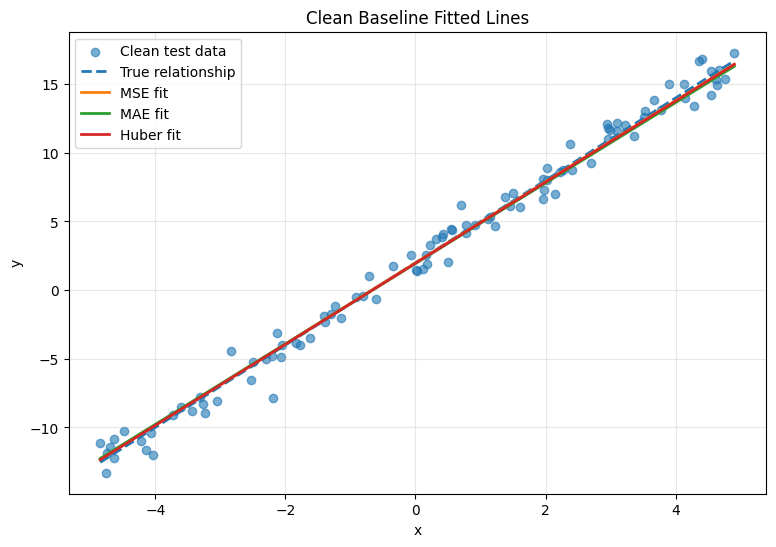

In [18]:
x_line = np.linspace(min(x_test), max(x_test), 300)
y_true_line = W_TRUE * x_line + B_TRUE

plt.figure(figsize=(9, 6))
plt.scatter(x_test, y_test, alpha=0.6, label="Clean test data")
plt.plot(x_line, y_true_line, linestyle="--", linewidth=2, label="True relationship")
plt.plot(x_line, predict(x_line, w_mse, b_mse), linewidth=2, label="MSE fit")
plt.plot(x_line, predict(x_line, w_mae, b_mae), linewidth=2, label="MAE fit")
plt.plot(x_line, predict(x_line, w_huber, b_huber), linewidth=2, label="Huber fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Clean Baseline Fitted Lines")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Conclusion

This experiment implemented one-dimensional linear regression from scratch using MSE, MAE, and Huber loss. All three analytical gradient implementations passed finite-difference verification and were used successfully in batch gradient descent training.

On the clean dataset with Gaussian noise, all three models learned slopes and intercepts close to the ground truth and produced similar RMSE, MAE, and fitted regression lines on the independent test set. MSE had slightly lower test error in this baseline, but the overall differences among the methods were small.

The experiment demonstrates that when the model structure, training data, and optimization procedure are fixed, different loss functions produce different gradients through their residual penalties. These gradients affect the parameter updates and final models. Under the current clean setting, however, these differences resulted in only small differences in final performance.